<a href="https://colab.research.google.com/github/A-ghori/sklearn/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


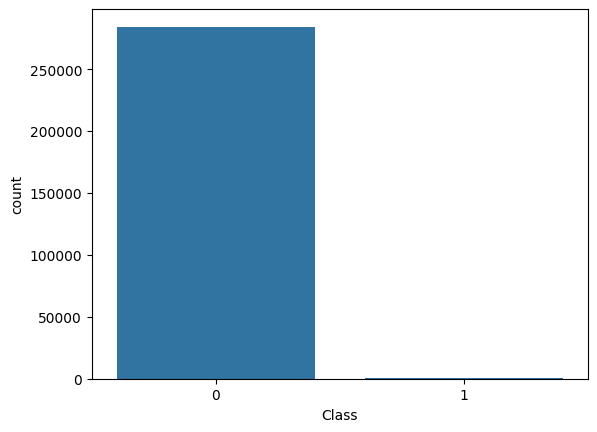

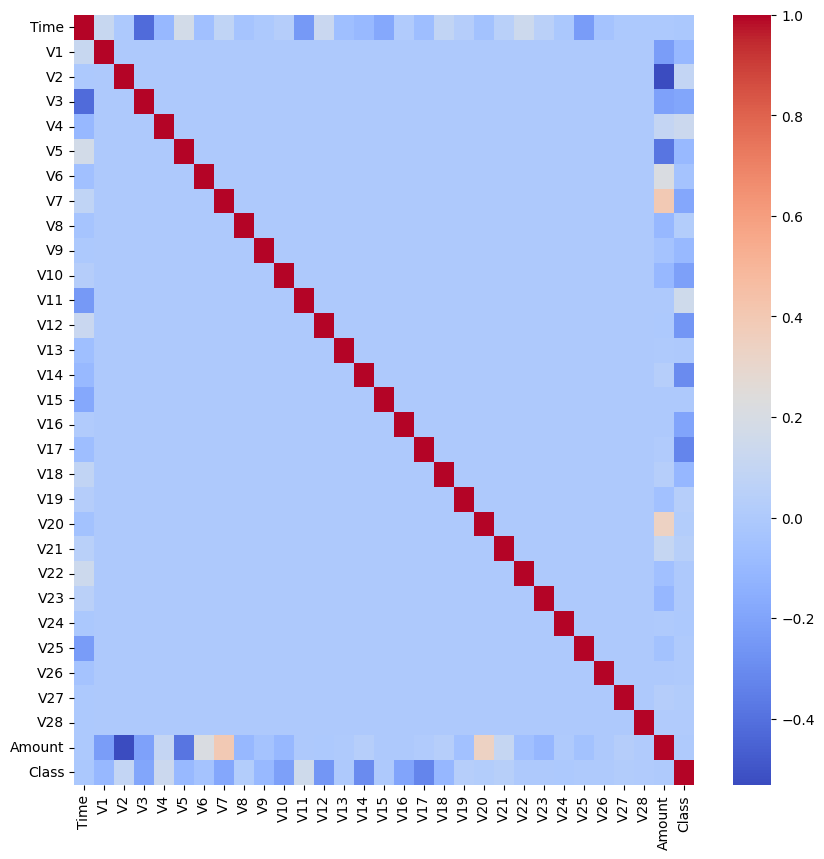

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [2]:
df = pd.read_csv('/content/creditcard.csv')
df.head()
df.describe()
print(df.columns)
df["Class"].unique()
df['Class'].value_counts()
# Class distribution
sns.countplot(x="Class",data=df)
plt.show()

# Coorelation matric
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

df.shape
df.info()
df.isnull().sum()


# Because your dataset is highly imbalanced.

In your fraud dataset, most transactions are legitimate and very few are fraud. So if we train ordinary Logistic Regression, the loss is dominated by the majority class.

#Without class_weight="balanced"

Suppose, conceptually:

Normal transactions = 284,000
Fraud transactions  =     500

The model can reduce the overall loss substantially by becoming very good at predicting normal transactions, even if it misses some fraud.

That's dangerous because:

For fraud detection, missing a fraud (FN) can be much more costly than incorrectly flagging a legitimate transaction (FP).

#What balanced actually does
#When you write:
model = LogisticRegression(class_weight="balanced")
Scikit-learn gives each class a weight approximately:
wc= N / K×Nc
where:
N = total samples
K = number of classes
Nc = number of samples in that class
So because:
Normal → huge number of samples
, Fraud  → tiny number of samples

you get:

Normal → smaller weight
, Fraud  → larger weight

In [3]:
from pandas.core.tools.datetimes import Scalar
from sklearn.model_selection import train_test_split
X = df.drop("Class", axis=1)
y = df["Class"]
print(X.shape)
print(y.shape)
print(y.isnull().sum())
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42,stratify=y) # stratify=y means Train and test me dono mein fraud/normal ka proportion approx same rakho
print(df['Class'].isnull().sum())
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight="balanced")
model.fit(X_train,y_train)
model.score(X_train, y_train)

print("Train:", model.score(X_train, y_train))
print("Test :", model.score(X_test, y_test))

(284807, 30)
(284807,)
0
0
Train: 0.976128508415809
Test : 0.9755275446789088


# Validation Testing so why we use it -->
Validation set is where you make decisions about the model. Test set is where you stop making decisions and just measure the final result.After training with class_weight="balanced", we're still not satisfied with simply using the default threshold. So before evaluating on the test dataset, we use the validation dataset to choose the appropriate threshold. Once the threshold is finalized, we use it on the untouched test dataset for the final evaluation


                 284,807
                    │
          ┌─────────┴─────────┐
          │                   │
       Training              Test
        80%                   20%
          │
          │
      split again
          │
     ┌────┴────┐
     │         │
   Train     Validation

In [6]:
# X_train, X_val , y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size = 0.2,
    random_state = 42,
    stratify = y_train #stratify=y_train ka matlab: Naye Train aur Validation sets mein bhi original training data ka class ratio preserve karo.
)

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy is",accuracy)

print("Confussion Matrix", confusion_matrix(y_val, y_pred))
print(classification_report(y_pred, y_val))

Accuracy is 0.9746757664201541
Confussion Matrix [[44343  1147]
 [    7    72]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     44350
           1       0.91      0.06      0.11      1219

    accuracy                           0.97     45569
   macro avg       0.94      0.53      0.55     45569
weighted avg       0.97      0.97      0.96     45569



In [12]:
y_prob = model.predict_proba(X_val)[:,1] # all rows column index 1 , i need that prob which is class 1 col probability
print(y_prob)
for threshold in [0.05, 0.10, 0.15, 0.20, 0.25,
              0.30, 0.35, 0.40, 0.45, 0.50, 0.29]:
  y_pred = (y_prob > threshold).astype(int)

  print("\nThreshold:", threshold)
  print(confusion_matrix(y_val, y_pred))
  print(classification_report(y_val, y_pred))

[0.07373326 0.12796259 0.00180506 ... 0.0040961  0.00029709 0.15019192]

Threshold: 0.05
[[30475 15015]
 [    1    78]]
              precision    recall  f1-score   support

           0       1.00      0.67      0.80     45490
           1       0.01      0.99      0.01        79

    accuracy                           0.67     45569
   macro avg       0.50      0.83      0.41     45569
weighted avg       1.00      0.67      0.80     45569


Threshold: 0.1
[[36454  9036]
 [    1    78]]
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     45490
           1       0.01      0.99      0.02        79

    accuracy                           0.80     45569
   macro avg       0.50      0.89      0.45     45569
weighted avg       1.00      0.80      0.89     45569


Threshold: 0.15
[[39334  6156]
 [    3    76]]
              precision    recall  f1-score   support

           0       1.00      0.86      0.93     45490
           1       0.0

#After evaluating different thresholds on the validation set, I selected 0.50 because it provides a good trade-off between fraud recall and false positives. At this threshold, the model detects 72 out of 79 fraud cases while producing 1,147 false positives."

In [18]:
# FINAL TEST REPORT
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy", accuracy)


print("Confussion Matrix", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy 0.9755275446789088
Confussion Matrix [[55478  1386]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

